In [11]:
# IMPORTING THE LIBRARIES
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np
import matplotlib.pyplot as plt
# LOADING THE DATASET
ratings = pd.read_csv('/content/ratings.csv')
movies = pd.read_csv('/content/movies.csv')

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

print("\nRatings sample:")
print(ratings.head())

print("\nMovies sample:")
print(movies.head())

Ratings shape: (100836, 4)
Movies shape: (9742, 3)

Ratings sample:
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

Movies sample:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


In [12]:
# MERGING MOVIES AND RATINGS INTO ON BASED ON MOVIEID
df = pd.merge(ratings, movies, on='movieId')
print(df.head())
print(df.shape)

print(df.isnull().sum())
df = df.drop('timestamp', axis=1)

   userId  movieId  rating  timestamp                        title  \
0       1        1     4.0  964982703             Toy Story (1995)   
1       1        3     4.0  964981247      Grumpier Old Men (1995)   
2       1        6     4.0  964982224                  Heat (1995)   
3       1       47     5.0  964983815  Seven (a.k.a. Se7en) (1995)   
4       1       50     5.0  964982931   Usual Suspects, The (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                               Comedy|Romance  
2                        Action|Crime|Thriller  
3                             Mystery|Thriller  
4                       Crime|Mystery|Thriller  
(100836, 6)
userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64


In [13]:
# PERFORMING FEATURE ENGINEERING
df['year'] = df['title'].str.extract(r'\((\d{4})\)')
df['year'] = pd.to_numeric(df['year'], errors='coerce')

df['main_genre'] = df['genres'].str.split('|').str[0]

df = df.drop(['title', 'genres'], axis=1)

le = LabelEncoder()
df['main_genre'] = le.fit_transform(df['main_genre'])

print(df.head())
print(df.dtypes)
print(df.shape)

   userId  movieId  rating    year  main_genre
0       1        1     4.0  1995.0           2
1       1        3     4.0  1995.0           5
2       1        6     4.0  1995.0           1
3       1       47     5.0  1995.0          13
4       1       50     5.0  1995.0           6
userId          int64
movieId         int64
rating        float64
year          float64
main_genre      int64
dtype: object
(100836, 5)


In [14]:
# SPLITING X AND Y
X = df.drop('rating', axis=1)
y = df['rating']

# TRAIN TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# TRAINING MODEL
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# MODEL PREDICTION AND EVALUATION
predictions = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mae = mean_absolute_error(y_test, predictions)

print("RMSE:", round(rmse, 4))
print("MAE:", round(mae, 4))

RMSE: 0.9914
MAE: 0.76


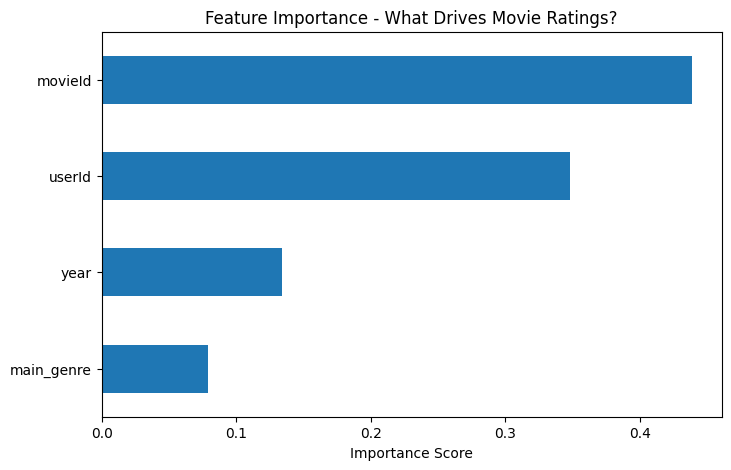

   Actual  Predicted
0     4.5        3.8
1     3.0        2.3
2     3.0        2.2
3     4.0        3.7
4     4.0        3.7
5     4.0        2.9
6     3.5        3.6
7     4.5        4.9
8     0.5        4.0
9     3.5        3.3


In [15]:
# FEATURE IMORTANCE PLOT TO CHECK WHICH FEATURE EFFECT THE PREDICTION MOST
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=True).plot(kind='barh', figsize=(8, 5))
plt.title('Feature Importance - What Drives Movie Ratings?')
plt.xlabel('Importance Score')
plt.show()

# ACTUAL VS PREDICTED COMPARISON
comparison = pd.DataFrame({'Actual': y_test[:10].values,
                           'Predicted': predictions[:10].round(1)})
print(comparison)